In [1]:
import numpy as np


def simulate_eden_brown_2004_linear():
    dt = 0.020  # seconds
    total_time = 8000.0  # seconds
    n_total_steps = int(total_time / dt)

    time = np.arange(0, total_time, dt)

    speed = 125.0  # cm/s
    track_length = 300.0  # cm

    run1 = np.arange(0, track_length, speed * dt)
    run2 = np.arange(track_length, 0, -speed * dt)
    run = np.concatenate((run1, run2))

    position = np.concatenate([run] * int(np.ceil(n_total_steps / run.shape[0])))
    position = position[:n_total_steps]

    true_params1 = np.array([np.log(10.0), 250.0, np.sqrt(12.0)])
    true_params2 = np.array([np.log(30.0), 150.0, np.sqrt(20.0)])

    # Interpolate between true_params1 and true_params2
    true_params = np.linspace(true_params1, true_params2, n_total_steps)
    log_max_rate, place_field_center, scale = true_params.T
    true_rate = np.exp(
        log_max_rate - (position - place_field_center) ** 2 / (2 * scale**2)
    )
    spike_indicator = np.random.poisson(true_rate * dt)

    return time, position, spike_indicator, dt, true_params


time, position, spike_indicator, dt, true_params = simulate_eden_brown_2004_linear()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [ ]:
from patsy import dmatrix
from scipy.interpolate import splev
import jax.numpy as jnp


def bspline(
    sample_pts: jnp.ndarray,
    knots: jnp.ndarray,
    order: int = 4,
    der: int = 0,
    outer_ok: bool = False,
) -> jnp.ndarray:
    """
    Calculate and return the evaluation of B-spline basis.

    This function evaluates B-spline basis for given sample points. It checks for
    out of range points and optionally handles them. It also handles the NaNs if present.

    Parameters
    ----------
    sample_pts :
        An array containing sample points for which B-spline basis needs to be evaluated,
        shape (n_samples,)
    knots :
        An array containing knots for the B-spline basis. The knots are sorted in ascending order.
    order :
        The order of the B-spline basis.
    der :
        The derivative of the B-spline basis to be evaluated.
    outer_ok :
        If True, allows for evaluation at points outside the range of knots.
        Default is False, in which case an assertion error is raised when
        points outside the knots range are encountered.

    Returns
    -------
    basis_eval :
        An array containing the evaluation of B-spline basis for the given sample points.
        Shape (n_samples, n_basis_funcs).

    Raises
    ------
    AssertionError
        If `outer_ok` is False and the sample points lie outside the B-spline knots range.

    Notes
    -----
    The function uses splev function from scipy.interpolate library for the basis evaluation.
    """
    knots.sort()
    nk = knots.shape[0]

    # check for out of range points (in cyclic b-spline need_outer must be set to False)
    need_outer = any(sample_pts < knots[order - 1]) or any(
        sample_pts > knots[nk - order]
    )
    # assert (
    #     not need_outer
    # ) | outer_ok, 'sample points must lie within the B-spline knots range unless "outer_ok==True".'

    # select knots that are within the knots range (this takes care of eventual NaNs)
    in_sample = (sample_pts >= knots[0]) & (sample_pts <= knots[-1])

    if need_outer:
        reps = order - 1
        knots = np.hstack((np.ones(reps) * knots[0], knots, np.ones(reps) * knots[-1]))
        nk = knots.shape[0]
    else:
        reps = 0

    # number of basis elements
    n_basis = nk - order

    # initialize the basis element container
    basis_eval = np.full((n_basis - 2 * reps, sample_pts.shape[0]), np.nan)

    # loop one element at the time and evaluate the basis using splev
    id_basis = jnp.eye(n_basis, nk, dtype=jnp.int8)
    for i in range(reps, len(knots) - order - reps):
        basis_eval[i - reps, in_sample] = splev(
            sample_pts[in_sample], (knots, id_basis[i], order - 1), der=der
        )

    return basis_eval.T


def _generate_knots(
    sample_pts: jnp.ndarray,
    perc_low: float = 0.0,
    perc_high: float = 1.0,
    is_cyclic: bool = False,
    n_basis_funcs: int = 10,
    order: int = 4,
) -> jnp.ndarray:
    """
    Generate knot locations for spline basis functions.

    Parameters
    ----------
    sample_pts : (n_samples,)
        The sample points.
    perc_low
        The low percentile value, between [0,1).
    perc_high
        The high percentile value, between (0,1].
    is_cyclic : optional
        Whether the spline is cyclic.

    Returns
    -------
        The knot locations for the spline basis functions.

    Raises
    ------
    AssertionError
        If the percentiles or order values are not within the valid range.
    """
    # Determine number of interior knots.
    num_interior_knots = n_basis_funcs - order
    if is_cyclic:
        num_interior_knots += order - 1

    assert 0 <= perc_low <= 1, "Specify `perc_low` as a float between 0 and 1."
    assert 0 <= perc_high <= 1, "Specify `perc_high` as a float between 0 and 1."
    assert perc_low < perc_high, "perc_low must be less than perc_high."

    # clip to avoid numerical errors in case of percentile numerical precision close to 0 and 1
    # Spline basis have support on the semi-open [a, b)  interval, we add a small epsilon
    # to mx so that the so that basis_element(max(samples)) != 0
    mn = np.nanpercentile(sample_pts, np.clip(perc_low * 100, 0, 100))
    mx = np.nanpercentile(sample_pts, np.clip(perc_high * 100, 0, 100)) + 10**-8

    knot_locs = np.concatenate(
        (
            mn * np.ones(order - 1),
            np.linspace(mn, mx, num_interior_knots + 2),
            mx * np.ones(order - 1),
        )
    )
    return knot_locs


knots = _generate_knots(position, n_basis_funcs=15)


def log_spline_receptive_field_model(
    position: jnp.ndarray, params: jnp.ndarray
) -> jnp.ndarray:

    if position.ndim == 0:
        position = jnp.array([position])
    basis = bspline(
        position,
        knots,
        order=4,
    )
    return (basis @ params).squeeze()


steepest_descent_point_process_filter(
    init_mean_params=jnp.zeros(15),
    x=position,
    spike_indicator=spike_indicator,
    dt=dt,
    epsilon=jnp.diag(jnp.ones(15)),
    log_receptive_field_model=log_spline_receptive_field_model,
)

# plt.plot(np.linspace(0, 300), bspline(np.linspace(0, 300), _generate_knots(np.linspace(0, 300), n_basis_funcs=4), order=4))

log_spline_receptive_field_model(position[0], jnp.ones(15))

In [ ]:
import jax.numpy as jnp


def _generate_knots(
    sample_pts: jnp.ndarray,
    perc_low: float = 0.0,
    perc_high: float = 1.0,
    is_cyclic: bool = False,
    n_basis_funcs: int = 10,
    order: int = 4,
) -> jnp.ndarray:
    """
    Generate knot locations for spline basis functions.

    Parameters
    ----------
    sample_pts : (n_samples,)
        The sample points.
    perc_low
        The low percentile value, between [0,1).
    perc_high
        The high percentile value, between (0,1].
    is_cyclic : optional
        Whether the spline is cyclic.

    Returns
    -------
        The knot locations for the spline basis functions.

    Raises
    ------
    AssertionError
        If the percentiles or order values are not within the valid range.
    """
    # Determine number of interior knots.
    num_interior_knots = n_basis_funcs - order
    if is_cyclic:
        num_interior_knots += order - 1

    assert 0 <= perc_low <= 1, "Specify `perc_low` as a float between 0 and 1."
    assert 0 <= perc_high <= 1, "Specify `perc_high` as a float between 0 and 1."
    assert perc_low < perc_high, "perc_low must be less than perc_high."

    # clip to avoid numerical errors in case of percentile numerical precision close to 0 and 1
    # Spline basis have support on the semi-open [a, b)  interval, we add a small epsilon
    # to mx so that the so that basis_element(max(samples)) != 0
    mn = np.nanpercentile(sample_pts, np.clip(perc_low * 100, 0, 100))
    mx = np.nanpercentile(sample_pts, np.clip(perc_high * 100, 0, 100)) + 10**-8

    knot_locs = np.concatenate(
        (
            mn * np.ones(order - 1),
            np.linspace(mn, mx, num_interior_knots + 2),
            mx * np.ones(order - 1),
        )
    )
    return knot_locs


knots = _generate_knots(position, n_basis_funcs=30)
knots

In [2]:
import matplotlib.pyplot as plt

# x = position
x = np.linspace(0, 300)
# u = (x - knots[-4]) / (knots[4:] - knots[:-4])

u = (x[:, None] - knots[:-4][None]) / (knots[4:][None] - knots[:-4][None])


cardinal_spline_params = np.array(
    [
        [-0.5, 1.5, -1.5, 0.5],
        [1.0, -2.5, 2.0, -0.5],
        [-0.5, 0.0, 0.5, 0.0],
        [0.0, 1.0, 0.0, 0.0],
    ]
)

blah = np.stack([u**3, u**2, u, np.ones_like(u)], axis=2) @ cardinal_spline_params
blah.shape

NameError: name 'knots' is not defined

In [ ]:
(blah @ np.array([0, 1, 0, 0])).shape

In [ ]:
plt.plot(x, blah[:, 20, :])

In [ ]:
from patsy import dmatrix

bspline_basis = dmatrix(
    "bs(x, knots=knots) - 1", {"x": np.linspace(0, 300, 300), "knots": knots[4:-4]}
)
plt.plot(np.linspace(0, 300, 300), bspline_basis)
plt.xlabel("Position")

In [ ]:
# function [res] = bSplineBasis(t, knots, cur_basis, order)
# % Recursive Cox-DeBoor formula
# % evaluate ith b-spline basis function of order Order at the values in x, given
# % knot locations -- knots

# if order == -1
#     res = (t < knots(cur_basis + 1)) & (t >= knots(cur_basis));
# else
#     z0 = (t - knots(cur_basis)) / (knots(cur_basis + order + 1) - knots(cur_basis));
#     z0(isinf(z0) | isnan(z0)) = 0;
#     z1 = (knots(cur_basis + order + 2) - t)/ (knots(cur_basis + order + 2) - knots(cur_basis + 1));
#     z1(isinf(z1) | isnan(z1)) = 0;
#     res = z0 .* bSplineBasis(t, knots, cur_basis, order - 1) + z1 .* bSplineBasis(t, knots, cur_basis + 1, order - 1);
# end

# end

# for cur_basis = 1:bsplines.basisDim,
#     basisMatrix_temp(:, cur_basis) = bSplineBasis(t, knots, cur_basis, basisOrder);
# end

# basisMatrix = zeros(length(time), bsplines.basisDim);

# for time_ind = 1:length(t),
#     cur_t = t(time_ind);
#     basisMatrix(time == cur_t, :) = repmat(basisMatrix_temp(time_ind, :), [sum(time == cur_t) 1]);
# end

/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:73: RuntimeWarning: divide by zero encountered in divide
  z1 = jnp.where(denom1 == 0.0, 0.0, (knots[cur_basis + order + 1] - x) / denom1)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:73: RuntimeWarning: invalid value encountered in divide
  z1 = jnp.where(denom1 == 0.0, 0.0, (knots[cur_basis + order + 1] - x) / denom1)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:70: RuntimeWarning: divide by zero encountered in divide
  z0 = jnp.where(denom0 == 0.0, 0.0, (x - knots[cur_basis - 1]) / denom0)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:70: RuntimeWarning: invalid value encountered in divide
  z0 = jnp.where(denom0 == 0.0, 0.0, (x - knots[cur_basis - 1]) / denom0)


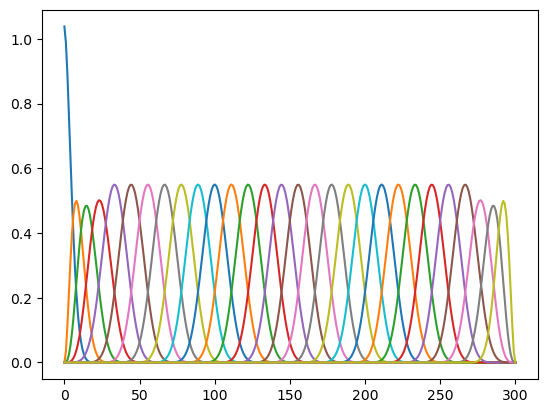

In [3]:
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt


def _generate_knots(
    sample_pts: jnp.ndarray,
    perc_low: float = 0.0,
    perc_high: float = 1.0,
    is_cyclic: bool = False,
    n_basis_funcs: int = 10,
    order: int = 4,
) -> jnp.ndarray:
    """
    Generate knot locations for spline basis functions.

    Parameters
    ----------
    sample_pts : (n_samples,)
        The sample points.
    perc_low
        The low percentile value, between [0,1).
    perc_high
        The high percentile value, between (0,1].
    is_cyclic : optional
        Whether the spline is cyclic.

    Returns
    -------
        The knot locations for the spline basis functions.

    Raises
    ------
    AssertionError
        If the percentiles or order values are not within the valid range.
    """
    # Determine number of interior knots.
    num_interior_knots = n_basis_funcs - order
    if is_cyclic:
        num_interior_knots += order - 1

    assert 0 <= perc_low <= 1, "Specify `perc_low` as a float between 0 and 1."
    assert 0 <= perc_high <= 1, "Specify `perc_high` as a float between 0 and 1."
    assert perc_low < perc_high, "perc_low must be less than perc_high."

    # clip to avoid numerical errors in case of percentile numerical precision close to 0 and 1
    # Spline basis have support on the semi-open [a, b)  interval, we add a small epsilon
    # to mx so that the so that basis_element(max(samples)) != 0
    mn = np.nanpercentile(sample_pts, np.clip(perc_low * 100, 0, 100))
    mx = np.nanpercentile(sample_pts, np.clip(perc_high * 100, 0, 100)) + 10**-8

    knot_locs = np.concatenate(
        (
            mn * np.ones(order - 1),
            np.linspace(mn, mx, num_interior_knots + 2),
            mx * np.ones(order - 1),
        )
    )
    return knot_locs


def calc_bspline_basis(x, knots, cur_basis, order):
    # Recursive Cox-DeBoor formula
    if order == -1:
        # Base case for recursion: Check if t is within the current knot interval
        return (x < knots[cur_basis]) & (x >= knots[cur_basis - 1])
    else:
        # Calculate z0 and z1 for the recursive formula
        denom0 = knots[cur_basis + order] - knots[cur_basis - 1]
        z0 = jnp.where(denom0 == 0.0, 0.0, (x - knots[cur_basis - 1]) / denom0)

        denom1 = knots[cur_basis + order + 1] - knots[cur_basis]
        z1 = jnp.where(denom1 == 0.0, 0.0, (knots[cur_basis + order + 1] - x) / denom1)

        # Recursive calculation of B-spline basis function
        return (z0 * calc_bspline_basis(x, knots, cur_basis, order - 1)) + (
            z1 * calc_bspline_basis(x, knots, cur_basis + 1, order - 1)
        )


# Vectorized version to compute basis matrix
def compute_basis_matrix(x, knots, basis_order=4):
    n_basis_dim = len(knots) - basis_order - 1  # Number of basis functions
    # Use list comprehension to compute basis functions for all cur_basis and stack them
    return jnp.stack(
        [
            calc_bspline_basis(x, knots, cur_basis, basis_order)
            for cur_basis in range(n_basis_dim)
        ], axis=-1
    )

knots = _generate_knots(position, n_basis_funcs=30)
spline_basis = compute_basis_matrix(np.arange(301), knots)

plt.plot(spline_basis);

In [4]:
def log_receptive_field_model(x, params):
    return (compute_basis_matrix(jnp.array([x]), knots) @ params).squeeze()

In [5]:
log_receptive_field_model(1, np.zeros((29,)))

Array(0., dtype=float32)

In [6]:
import jax
import jax.numpy as jnp

def steepest_descent_point_process_filter(
    init_mean_params: jnp.ndarray,
    x: jnp.ndarray,
    spike_indicator: jnp.ndarray,
    dt: float,
    epsilon: jnp.ndarray,
    log_receptive_field_model: callable,
) -> jnp.ndarray:
    """Steepest Descent Point Process Filter (SDPPF)

    Parameters
    ----------
    init_mean_params : jnp.ndarray, shape (n_params,)
    x : jnp.ndarray, shape (n_time,)
        linear-valued input signal
    spike_indicator : jnp.ndarray, shape (n_time,)
        Spike count
    dt : float
        Time step
    epsilon : jnp.ndarray, shape (n_params, n_params)
        Learning rate
    log_receptive_field_model : callable
        Function that takes in `x` and parameters and returns the log spike rate

    Returns
    -------
    posterior_mode : jnp.ndarray, shape (n_time, n_params)
    """
    grad_log_receptive_field_model = jax.grad(log_receptive_field_model, argnums=1)

    def _update(
        mode_prev: jnp.ndarray, args: tuple[jnp.ndarray, jnp.ndarray]
    ) -> tuple[jnp.ndarray, jnp.ndarray]:
        """Steepest Descent Point Process Filter update step"""
        x_t, spike_indicator_t = args
        conditional_intensity = jnp.exp(log_receptive_field_model(x_t, mode_prev))
        innovation = spike_indicator_t - conditional_intensity * dt
        one_step_grad = grad_log_receptive_field_model(x_t, mode_prev)
        posterior_mode = mode_prev + epsilon @ one_step_grad * innovation

        return posterior_mode, posterior_mode

    return jax.lax.scan(_update, init_mean_params, (x, spike_indicator))[1]

In [7]:
posterior_mode = steepest_descent_point_process_filter(
    init_mean_params=jnp.zeros(29),
    x=position,
    spike_indicator=spike_indicator,
    dt=dt,
    epsilon=jnp.diag(jnp.ones(29) * 10e-5),
    log_receptive_field_model=log_receptive_field_model,
)

In [9]:
rate = jnp.exp(posterior_mode @ compute_basis_matrix(np.arange(0, 300), knots).T)

/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_56718/1242419643.py:72: RuntimeWarning: divide by zero encountered in divide
  z1 = jnp.where(denom1 == 0.0, 0.0, (knots[cur_basis + order + 1] - x) / denom1)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_56718/1242419643.py:72: RuntimeWarning: invalid value encountered in divide
  z1 = jnp.where(denom1 == 0.0, 0.0, (knots[cur_basis + order + 1] - x) / denom1)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_56718/1242419643.py:69: RuntimeWarning: divide by zero encountered in divide
  z0 = jnp.where(denom0 == 0.0, 0.0, (x - knots[cur_basis - 1]) / denom0)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_56718/1242419643.py:69: RuntimeWarning: invalid value encountered in divide
  z0 = jnp.where(denom0 == 0.0, 0.0, (x - knots[cur_basis - 1]) / denom0)


In [10]:
compute_basis_matrix(np.arange(0, 300, 5), knots).shape

/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:73: RuntimeWarning: divide by zero encountered in divide
  z1 = jnp.where(denom1 == 0.0, 0.0, (knots[cur_basis + order + 1] - x) / denom1)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:73: RuntimeWarning: invalid value encountered in divide
  z1 = jnp.where(denom1 == 0.0, 0.0, (knots[cur_basis + order + 1] - x) / denom1)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:70: RuntimeWarning: divide by zero encountered in divide
  z0 = jnp.where(denom0 == 0.0, 0.0, (x - knots[cur_basis - 1]) / denom0)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:70: RuntimeWarning: invalid value encountered in divide
  z0 = jnp.where(denom0 == 0.0, 0.0, (x - knots[cur_basis - 1]) / denom0)


(60, 29)

In [11]:
rate = np.exp(posterior_mode @ compute_basis_matrix(np.arange(0, 300, 50), knots).T)

/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:73: RuntimeWarning: divide by zero encountered in divide
  z1 = jnp.where(denom1 == 0.0, 0.0, (knots[cur_basis + order + 1] - x) / denom1)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:73: RuntimeWarning: invalid value encountered in divide
  z1 = jnp.where(denom1 == 0.0, 0.0, (knots[cur_basis + order + 1] - x) / denom1)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:70: RuntimeWarning: divide by zero encountered in divide
  z0 = jnp.where(denom0 == 0.0, 0.0, (x - knots[cur_basis - 1]) / denom0)
/var/folders/86/m147b4k17lddvs_xsw0mj2zw0000gn/T/ipykernel_60950/1524154286.py:70: RuntimeWarning: invalid value encountered in divide
  z0 = jnp.where(denom0 == 0.0, 0.0, (x - knots[cur_basis - 1]) / denom0)
